In [12]:
import numpy as np
import gpt as g
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

import scipy
import math
from scipy import special as sp
import time

In [13]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize])
    return np.mean(resmpld)

def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [14]:
def autocorrelation2(samples, separation, max_separation, binsize):
    mean = np.mean(samples)
    ACF = []
    err = []
    t = -1
    nskip = int(0)
    #binsize = 50
    
    for i in range(int(max_separation / separation)):
        t += separation
        temp = []
        
        for i in range(np.size(samples)-t):
            temp.append((samples[i+t] - mean) * (samples[i] - mean))
        
        N2 = np.size(temp)
    
        jk = Jackknife( N2-nskip, binsize )
        jk.set( simple_mean, temp )
        jk.do_it()
        
        ACF.append(np.mean(temp))
        err.append(jk.err())
    
    x = np.arange(1, np.size(ACF))
    for i in x:
        ACF[i] /= ACF[0]
        err[i] /= ACF[0]
        
    err[0] = 0.
    ACF[0] = 1.
    
    
    return ACF, err

In [15]:
size = 64
grid = g.grid([size, size,], g.double)
rng = g.random(str(time.time()))

U = g.qcd.gauge.unit(grid)
rng.normal_element(U)

GPT :    3747.582646 s : Initializing gpt.random(1751405964.6322749,vectorized_ranlux24_389_64) took 0.00033617 s


[lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double)]

In [16]:
action_gauge = g.qcd.gauge.action.wilson(6.0)

metro = g.algorithms.markov.metropolis(rng)
inv = g.algorithms.inverter
sympl = g.algorithms.integrator.symplectic

log = sympl.log()
pure_gauge = True


In [17]:
# thermalize lattice first
beta = g.default.get_float("--beta", 2.0)
seed = g.default.get("--seed", "hmc-pure-gauge")
ntherm = g.default.get_int("--ntherm", 10)
n = g.default.get_int("--n", 200)
nwrite = g.default.get_int("--nwrite", 10)
g.default.set_verbose("omf4")

# conjugate momenta
mom = g.group.cartesian(U)

# Log
g.message(f"Lattice = {grid.fdimensions}")
g.message("Actions:")
# action for conj. momenta
a0 = g.qcd.scalar.action.mass_term()
g.message(f" - {a0.__name__}")

# wilson action 
a1 = g.qcd.gauge.action.wilson(beta)
g.message(f" - {a1.__name__}")
    
    
def hamiltonian():
    return a0(mom) + a1(U) 

# molecular dynamics
sympl = g.algorithms.integrator.symplectic
    
iphmc = sympl.update_p(mom, lambda: a1.gradient(U, U))
iqhmc = sympl.update_q(U, lambda: a0.gradient(mom, mom))

# integrator
mdint_hmc = sympl.leap_frog(20, iphmc, iqhmc)
#g.message(f"Integration scheme:\n{mdint}")
    
# metropolis
metro = g.algorithms.markov.metropolis(rng)
    
# MD units
tau = 2.0
g.message(f"tau = {tau} MD units")

def hmc(tau, mom):
    rng.normal_element(mom)
    accrej = metro(U)
    h0 = hamiltonian()
    mdint_hmc(tau)
    h1 = hamiltonian()
    return [accrej(h1, h0), h1 - h0]


# thermalization
for i in range(1, 20):
    h = []
    timer = g.timer("hmc")
    for _ in range(ntherm // 10):
        timer("trajectory")
        h += [hmc(tau, mom)]
    h = np.array(h)
    timer()
    g.message(f"{i*10} % of thermalization completed")
    g.message(timer)
    g.message(
        f"Plaquette = {g.qcd.gauge.plaquette(U)}, Acceptance = {np.mean(h[:,0]):.2f}, |dH| = {np.mean(np.abs(h[:,1])):.4e}"
    )


start = time.time()

# production
history = []
plaq = []


wf_energyHMC = []
for i in range(10):
    history += [hmc(tau, mom)]
    P = g.qcd.gauge.plaquette(U)
    plaq.append(P)
    g.message(f"Trajectory {i}, P={P}")
    #if i % nwrite == 0:
    #    g.save(f"ckpoint_lat.{seed}.{i}", U, g.format.nersc())

    """
    if i % 2 == 0:
        t = 0.0
        eps = 0.05
        U_wf = g.copy(U)
        
        for i in range(320): # t = 16
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)

        E = g.qcd.gauge.energy_density(U_wf)
        wf_energyHMC.append(E)
    """


end = time.time()
print("time taken = ", end - start)

history = np.array(history)
g.message(f"Acceptance rate = {np.mean(history[:,0]):.2f}")
g.message(f"<|dH|> = {np.mean(np.abs(history[:,1])):.4e}")



GPT :    3748.411573 s : Lattice = [64, 64]
GPT :    3748.412779 s : Actions:
GPT :    3748.413382 s :  - mass_term(m^-1 = 1.0)
GPT :    3748.413965 s :  - wilson(2.0)
GPT :    3748.414857 s : tau = 2.0 MD units
GPT :    3748.556366 s : 10 % of thermalization completed
GPT :    3748.556702 s : hmc:
                       : trajectory           1.41e-01 s (= 100.00 %); time/s = 1.41e-01/1.41e-01/1.41e-01 (min/max/avg)
GPT :    3748.557126 s : Plaquette = 0.1319414302844639, Acceptance = 1.00, |dH| = 3.1920e+00
GPT :    3748.674123 s : 20 % of thermalization completed
GPT :    3748.674497 s : hmc:
                       : trajectory           1.17e-01 s (= 100.00 %); time/s = 1.17e-01/1.17e-01/1.17e-01 (min/max/avg)
GPT :    3748.674886 s : Plaquette = 0.13117965442953586, Acceptance = 1.00, |dH| = 1.1543e-02
GPT :    3748.783929 s : 30 % of thermalization completed
GPT :    3748.784217 s : hmc:
                       : trajectory           1.09e-01 s (= 100.00 %); time/s = 1.09e-01/1.09

In [18]:
W = g.copy(U)
V = g.copy(U)

In [19]:
                                        # domain to be updated. even = False => odd
def freeze_connecting_links(block_size, even = True):
    domain_even = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.even)
    domain_odd = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.odd)

    if even:
        domain_parity = domain_even
    else:
        domain_parity = domain_odd
    
    def find_links_to_freeze(domain_parity):
        vol = domain_parity.block_volume
        links = []

        
        for i in range(domain_parity.number_of_local_blocks//2 ):
            domain =  domain_parity.gcoor[ vol*i : vol*(i+1) ] # pick out the coords in adjacent domains
                           # [x , mu] # block size picks out lower right hand point
            links.append( [domain[block_size-1], 0] )
                            
        return links

    
    def freeze_opposite_parity_blocks(even):
        if even:
            return domain_odd.gcoor
        else:
            return domain_even.gcoor
    
        #return frozen_sites

            # frozen sites                    additional frozen links
        
    def link_masks():
        frozen_sites = freeze_opposite_parity_blocks(even)
        frozen_links = find_links_to_freeze(domain_parity)

        mask = g.qcd.gauge.unit(grid)   
        
        for i in frozen_sites:
            mask[0][i] = 0.
            mask[1][i] = 0.
    
        for j in frozen_links:
            mask[j[1]][j[0]] = 0.

        return mask

    return link_masks()

In [20]:
def find_conjugate_block(block_size, even=True,mom = True):
    domain_even = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.even)
    domain_odd = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.odd)

    vol = block_size * block_size
    
    if even:
        coords = domain_even.gcoor
    else:
        coords = domain_odd.gcoor

    # distance from conjugate site in coords
    #conjugate_block_distance = (size // block_size // 2) * vol 
    #if mom:
    #    conjugate_block_distance *= -1 # roll forwards or backwards to get to momenta / coords (be careful to choose convention)
    
    #return np.roll(coords, conjugate_block_distance) # roll forward to line up coords with conjugate blocl
    return coords

def coordinate_mask(block_size, even = True):
    vol = block_size * block_size
    
    if even:
        conjugate_site_locations = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.even).gcoor
    else:
        conjugate_site_locations = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.odd).gcoor

    blocks_per_line = size // block_size // 2
    skip = vol * blocks_per_line 
     
    idx  = np.arange(conjugate_site_locations.shape[0]) # I actually want to keep all blocks on one line, freeeze all those on the next...
    mask = ((idx // skip) % 2) == 0 # create mask to keep 4, skip 4, keep 4 etc

    # but is this really doing what I think its doing? I roll the list of coords forward then keep some, discard others, 
    # but is this really just not doing anything? This would seem to be the case if I roll by the same number as would be deleted anyway...
    # would probably be correct to just not roll at all...
    coord_mask = conjugate_site_locations[mask] # apply mask 

    mask = g.qcd.gauge.unit(grid) 
        
    for i in coord_mask:
        mask[0][i] = 0. # make actual matrix of masks to multiply into the gradient.
        mask[1][i] = 0.

    return mask
    
def momentum_mask(block_size, even = True):
    vol = block_size * block_size
    
    if even:
        conjugate_site_locations = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.even).gcoor
    else:
        conjugate_site_locations = g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.odd).gcoor

    blocks_per_line = size // block_size // 2
    skip = vol * blocks_per_line
    
    idx  = np.arange(conjugate_site_locations.shape[0])
    mask = ((idx // skip) % 2) == 1
    
    mom_mask = conjugate_site_locations[mask]
    
    mask = g.qcd.gauge.unit(grid)   
        
    for i in mom_mask:
        mask[0][i] = 0.
        mask[1][i] = 0.

    return mask


In [25]:
def MC_Ham(U):
    return action_gauge(U)

def domains_U(block_size):
    return g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.even), \
           g.domain.even_odd_blocks(grid, [block_size for i in range(grid.nd)], g.odd)


def gauge_force_coord_update(frozen_links, momenta_mask, block_size):
    # calculate gradients
    V = action_gauge.gradient(U, U)
    
    # shift to other domain
    for i in range(grid.nd):
        V[0] = g.cshift(V[0], i, block_size)
        V[1] = g.cshift(V[1], i, block_size)

    """
    # freeze links
    frozen_sites, frozen_links = frozen

    for i in frozen_sites:
        V[0][i] = 0.
        V[1][i] = 0.

    for j in frozen_links:
        V[j[1]][j[0]] = 0.
    """
    V[0] @= g(V[0] * frozen_links[0] * momenta_mask[0]) # also need mask to block the other active domain!!!
    V[1] @= g(V[1] * frozen_links[1] * momenta_mask[1])

    #print(V)
    
    x = log(lambda: V , "gauge")()
    
    return x

def gauge_force_mom_update(frozen_links, coordinate_mask, block_size):

     # calculate gradients
    V = action_gauge.gradient(U, U)
    
    # shift to other domain
    for i in range(grid.nd):
        V[0] = g.cshift(V[0], i, -block_size)
        V[1] = g.cshift(V[1], i, -block_size)

    """
    # freeze links
    frozen_sites, frozen_links = frozen

    for i in frozen_sites:
        V[0][i] = 0.
        V[1][i] = 0.

    for j in frozen_links:
        V[j[1]][j[0]] = 0.
    
    x = log(lambda: V , "gauge")()
    """
    V[0] @= g(V[0] * frozen_links[0] * coordinate_mask[0])
    V[1] @= g(V[1] * frozen_links[1] * coordinate_mask[1])
    
    
    x = log(lambda: V , "gauge")()
    
    return x

block_size = 32

even = True
frozen22 = freeze_connecting_links(block_size, even)
coord_mask = coordinate_mask(block_size, even)
mom_mask = momentum_mask(block_size, even)


iq_1 = sympl.update_q(
    U, log(lambda: gauge_force_coord_update(frozen22, mom_mask, block_size), "gauge_force_coord_update")
)

iq_2 = sympl.update_p(
    U, log(lambda: gauge_force_mom_update(frozen22, coord_mask, block_size), "gauge_force_mom_update")
)

# integrator
mdintMC = sympl.leap_frog(40, iq_1, iq_2)

block_sizeodd = 32

even = False
frozen22odd = freeze_connecting_links(block_size, even)
coord_maskodd = coordinate_mask(block_size, even)
mom_maskodd = momentum_mask(block_size, even)


iq_1odd = sympl.update_q(
    U, log(lambda: gauge_force_coord_update(frozen22odd, mom_maskodd, block_sizeodd), "gauge_force_coord_update")
)

iq_2odd = sympl.update_p(
    U, log(lambda: gauge_force_mom_update(frozen22odd, coord_maskodd, block_sizeodd), "gauge_force_mom_update")
)

# integrator
mdintMCodd = sympl.leap_frog(40, iq_1odd, iq_2odd)


g.message(f"Integration scheme:\n{mdintMC}")
g.message(f"Integration scheme:\n{mdintMCodd}")

GPT :    3856.559541 s : Integration scheme:
                       : leap_frog(40, Q, P)
                       :   Q(0.0125, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
                       :   P(0.025, 0)
                       :   Q(0.025, 0)
            

21434.04567660423
21434.03099962793
21434.045069527798
21434.033263552526
21434.053340651182
21434.022839087847
21434.026764204154
21433.97683142544
21433.97145950517
21434.00693677313
21433.990590073023
21433.949995972507
21433.998322045576
21433.932775874222
21433.94155394523
21433.95206273658
21433.990967290476
21434.004441347533
21434.00447858731
21434.020172955916
21433.974367787512
21434.021909459483
21433.98587123985
21433.971456852953
21433.943514034294


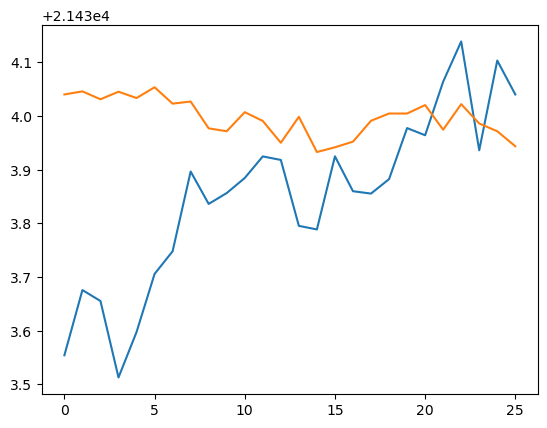

In [26]:
energies1 = [MC_Ham(U)]

for i in range(25):
    mdintMC(1.)
    energies1.append(MC_Ham(U))
    print(energies1[-1])

plt.plot(energies)
plt.plot(energies1)

In [24]:

sblock_size = 8

seven = True
sfrozen22 = freeze_connecting_links(sblock_size, seven)
scoord_mask = coordinate_mask(sblock_size, seven)
smom_mask = momentum_mask(sblock_size, seven)


siq_1 = sympl.update_q(
    U, log(lambda: gauge_force_coord_update(sfrozen22, smom_mask, sblock_size), "gauge_force_coord_update")
)

siq_2 = sympl.update_p(
    U, log(lambda: gauge_force_mom_update(sfrozen22, scoord_mask, sblock_size), "gauge_force_mom_update")
)

# integrator
smdintMC = sympl.leap_frog(20, siq_1, siq_2)

sblock_sizeodd = 8

seven = False
sfrozen22odd = freeze_connecting_links(sblock_size, seven)
scoord_maskodd = coordinate_mask(sblock_size, seven)
smom_maskodd = momentum_mask(sblock_size, seven)


siq_1odd = sympl.update_q(
    U, log(lambda: gauge_force_coord_update(sfrozen22odd, smom_maskodd, sblock_sizeodd), "gauge_force_coord_update")
)

siq_2odd = sympl.update_p(
    U, log(lambda: gauge_force_mom_update(sfrozen22odd, scoord_maskodd, sblock_sizeodd), "gauge_force_mom_update")
)

# integrator
smdintMCodd = sympl.leap_frog(20, siq_1odd, siq_2odd)

g.message(f"Integration scheme:\n{smdintMC}")
g.message(f"Integration scheme:\n{smdintMCodd}")

KeyboardInterrupt: 

In [ ]:

energies1 = [MC_Ham(W)]

for i in range(25):
    mdintMC(tau)
    mdintMC(-tau)
    energies1.append(MC_Ham(W))
    print("traj = ", i , "ham = ", energies1[-1])

In [ ]:
#plt.plot(energies, color='r')
plt.plot(energies1, color='orange')
#plt.plot(energies3, color='g') # 

In [32]:
dwfeMC2 = []
dwfeHMC2 = []
eps = 0.05
for j in range(20):
    for i in range(1):
        U_wf = g.copy(U)
                    
        for l in range(320): # t = 16
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
        Ei = g.qcd.gauge.energy_density(U_wf)
        
        
        mdintMC(tau)
        mdintMCodd(tau)
        smdintMC(tau)
        smdintMCodd(tau)
        #hmc(tau, mom)
        #tau1*= 1.2
        
        U_wf = g.copy(U)
                    
        for l in range(320): # t = 16
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
        Ef = g.qcd.gauge.energy_density(U_wf)
        
        dwfeMC2.append(Ef - Ei)
        print("traj = ", j, "delta E  ", dwfeMC2[-1])

    
    for i in range(1):
        U_wf = g.copy(U)
                    
        for l in range(320): # t = 16
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
        Ei = g.qcd.gauge.energy_density(U_wf)
        
        
        #mdintMC(tau1)
        hmc(tau, mom)
        hmc(tau, mom)
    
        U_wf = g.copy(U)
                    
        for l in range(320): # t = 16
            U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
            
        Ef = g.qcd.gauge.energy_density(U_wf)
        
        dwfeHMC2.append(Ef - Ei)
    
        print("traj = ", j, "delta  ", dwfeHMC2[-1])


traj =  0 delta E   (-1.1510573399589694e-05-3.555755616867222e-39j)
traj =  0 delta   (-7.712842841060721e-05-7.605127025583647e-40j)
traj =  1 delta E   (0.00011184555963462332+3.811173090556635e-39j)
traj =  1 delta   (-0.00010113042402439833-3.943904081097482e-39j)
traj =  2 delta E   (8.19735899701662e-05-9.635552448451734e-40j)
traj =  2 delta   (2.892516656961353e-06+5.5589173768134055e-39j)
traj =  3 delta E   (-4.933213800056835e-05-3.9919742236176805e-39j)
traj =  3 delta   (5.63464514179605e-05-3.174064335960571e-39j)
traj =  4 delta E   (-2.5430441410607182e-05+4.626213118958807e-39j)
traj =  4 delta   (-7.389721137855915e-05+1.4406693459784871e-39j)
traj =  5 delta E   (-2.3390362473247792e-05-4.850062140843911e-39j)
traj =  5 delta   (2.1278814332886288e-05+2.318846277989278e-39j)
traj =  6 delta E   (-9.326521144836634e-05+1.9773330266517483e-39j)
traj =  6 delta   (0.00014873115493681786-2.901427706741535e-39j)
traj =  7 delta E   (-0.0001495114866472601+5.3235889179085

In [33]:
M = [abs(x) for x in dwfeMC2]
print("MC", np.mean(np.asarray(M)), np.std(np.asarray(M)))

M = [abs(x) for x in dwfeHMC2]
print("HMC", np.mean(np.asarray(M)), np.std(np.asarray(M)))
# 16

# This doesn't really seem to be a good measure. Will probably need 3 and 4 D then measure topological charge

MC 8.371040874506992e-05 5.323160450900438e-05
HMC 8.199954664758538e-05 5.337397296045214e-05


In [ ]:
M = [abs(x) for x in dwfeMC2]
print("MC", np.mean(np.asarray(M)), np.std(np.asarray(M)))

M = [abs(x) for x in dwfeHMC2]
print("HMC", np.mean(np.asarray(M)), np.std(np.asarray(M)))
# 32

In [20]:
# production
history = []
plaqMC = []
wf_energy = []

tau1 = tau*0.5

start = time.time()

ff = 0
for i in range(10):
    for j in range(1):
        history += [hmc(tau, mom)]
        ff += 1
    print("hmc ", g.qcd.gauge.plaquette(U))

    # should mix these in more because swapping directions almost undoes 90 percent of the work
    for k in range(9):
        ff += 1
        en1 = MC_Ham(U)
        V = g.copy(U) # should give wrong asnwer though unless I randomly choose t direction
        if np.random.randint(0,2) == 0:
            tau1 *= -1 # I am just going back and forth!!!
        mdintMC(tau1)
        en2 = MC_Ham(U)
        print("MC ", g.qcd.gauge.plaquette(U))
        if np.exp(- (en2 - en1)) < np.random.uniform(0,1):
            #U[:] @= V[:]
            U[0] @= V[0]
            U[1] @= V[1]
            print("REJECT", "DELTA S = ", en2 - en1 )
        
        if ff % 2 == 0:
            t = 0.0
            eps = 0.05
            U_wf = g.copy(U)
            
            for l in range(320): # t = 8
                U_wf = g.qcd.gauge.smear.wilson_flow(U_wf, epsilon=eps)
    
            E = g.qcd.gauge.energy_density(U_wf)
            wf_energy.append(E)
    
    P = g.qcd.gauge.plaquette(U)
    plaqMC.append(P) 
    
    g.message(f"Trajectory {i}, P={P}")
    #if i % nwrite == 0:
    #    g.save(f"ckpoint_lat.{seed}.{i}", U, g.format.nersc())


end = time.time()
print("time taken = ", end - start)

history = np.array(history)
g.message(f"Acceptance rate = {np.mean(history[:,0]):.2f}")
g.message(f"<|dH|> = {np.mean(np.abs(history[:,1])):.4e}")

hmc  0.6205885276193673
MC  0.6205854478644204
MC  0.6205885276193603
MC  0.6205926043699506
MC  0.6205986396742977
MC  0.6205926043699437
MC  0.6205986396742907
MC  0.6205892657825727
MC  0.620598639674284
MC  0.6205892657825657
GPT :     689.175340 s : Trajectory 0, P=0.6205892657825657
hmc  0.6194502910111447
MC  0.6194502088704802
MC  0.619452532469261
MC  0.6194502088704733
MC  0.6194502910111309
MC  0.6194502088704663
MC  0.619452532469247
MC  0.6194486326696841
MC  0.6194525324692401
MC  0.6194502088704524
GPT :     728.544769 s : Trajectory 1, P=0.6194502088704524
hmc  0.6185654310988362
MC  0.6185593034294534
REJECT DELTA S =  0.2509893379192363
MC  0.6185589455840712
MC  0.6185594496834002
MC  0.6185589455840643
MC  0.6185654310988223
MC  0.6185593034294394
MC  0.6185654310988155
MC  0.6185593034294325
MC  0.6185654310988085
GPT :     767.979203 s : Trajectory 2, P=0.6185654310988085
hmc  0.6143453965247211
MC  0.6143455561600145
MC  0.6143453965247141
MC  0.6143455561600075


10
0.615978223588054
0.0028702249365384703


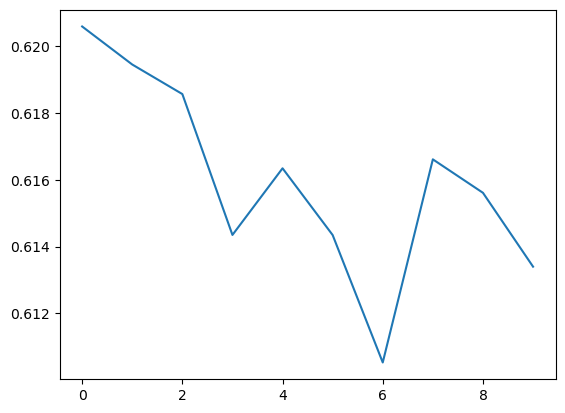

In [22]:
print(len(plaqMC))
print(np.mean(plaqMC))
print(np.std(plaqMC))

plt.plot(plaqMC)

#0.6182843801630405
#0.0018838648675919768

In [26]:
print(len(plaq[0:-1:10]))
print(len(plaq_samp))

10
10


(0.0008500715814509259+1.1879782385812645e-40j)
7.179945409193131e-05


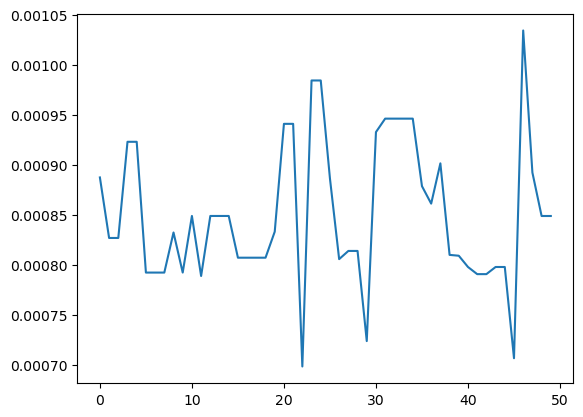

In [27]:
print(np.mean(wf_energy))
print(np.std(wf_energy))
plt.plot(wf_energy)

#(0.0030426871200031885+9.885789940980357e-40j)
#0.00012500012015086935

In [30]:
wf_energy

[np.complex128(0.0008872313025100398-5.022253696140144e-40j),
 np.complex128(0.0008267279846214287+1.2254299018581952e-39j),
 np.complex128(0.0008267279846214271+6.715470656553107e-40j),
 np.complex128(0.0009228670228665051-5.883211472621312e-40j),
 np.complex128(0.0009228670228665082+1.259868212917442e-39j),
 np.complex128(0.000792131530388456-9.126152430700377e-40j),
 np.complex128(0.0007921315303884589-1.4349296274686127e-41j),
 np.complex128(0.0007921315303884551-4.591774807899561e-41j),
 np.complex128(0.0008322018018597889+4.1325973271096045e-40j),
 np.complex128(0.0007921315303884696-5.165746658887006e-40j),
 np.complex128(0.0008487201447109185+6.801566434201224e-40j),
 np.complex128(0.0007887248747292854+1.8941071082585687e-39j),
 np.complex128(0.0008487201447109317-3.4553105429444193e-39j),
 np.complex128(0.0008487201447109255+2.1552643004578562e-39j),
 np.complex128(0.0008487201447109201-5.911910065170684e-40j),
 np.complex128(0.0008070004241501514-7.461634062836786e-41j),
 np

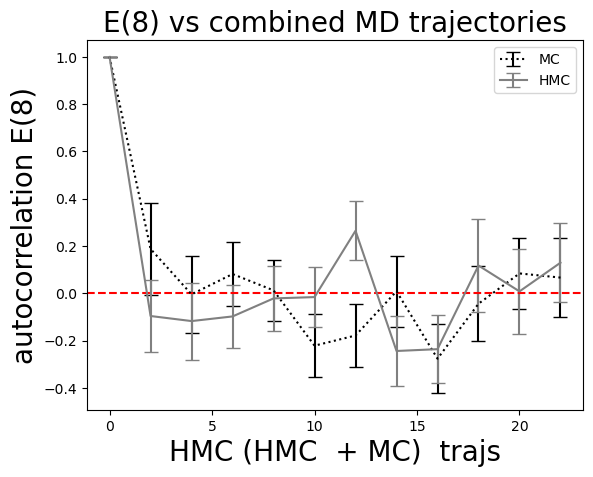

In [29]:
MC = autocorrelation2(wf_energy, 1, 12, 1)
HMC = autocorrelation2(wf_energyHMC, 1, 12, 1)


plt.title("E(8) vs combined MD trajectories", size=20 )
plt.ylabel("autocorrelation E(16)", size=20)
plt.xlabel("HMC (HMC  + MC)  trajs",size=20)
plt.errorbar(np.arange(len(MC[0]))*2, MC[0], MC[1], color='black', label='MC', capsize=5, linestyle=':') # MC
plt.errorbar(np.arange(len(HMC[0]))*2, HMC[0], HMC[1], color= 'grey', label="HMC", capsize=5) #HMC
plt.axhline(y=0, color='red', linestyle='--')
plt.legend()
#plt.savefig("2D_100_E16_AC.pdf")

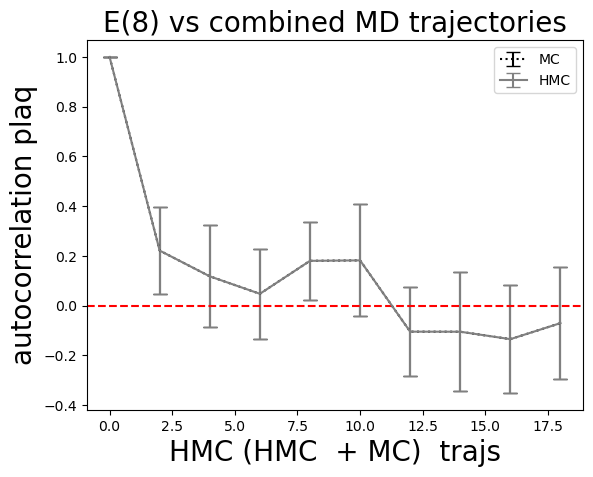

In [95]:
MC = autocorrelation2(plaq[0:-1:10], 1, 10, 1)
HMC = autocorrelation2(plaq_samp, 1, 10, 1)

plt.title("E(8) vs combined MD trajectories", size=20 )
plt.ylabel("autocorrelation plaq", size=20)
plt.xlabel("HMC (HMC  + MC)  trajs",size=20)
plt.errorbar(np.arange(len(MC[0]))*2, MC[0], MC[1], color='black', label='MC', capsize=5, linestyle=':') # MC
plt.errorbar(np.arange(len(HMC[0]))*2, HMC[0], HMC[1], color= 'grey', label="HMC", capsize=5) #HMC
plt.axhline(y=0, color='red', linestyle='--')
plt.savefig("2D_200_plaq_AC.pdf")
plt.legend()